# 🤖 Classification — Phân loại AQI 6 mức | Hà Nội 2022–2025
> **Pipeline:** Random Forest → XGBoost  
> **Xử lý mất cân bằng:** `class_weight` / `scale_pos_weight` (thay vì SMOTE)  
> **Đánh giá:** F1-macro · ROC-AUC · Confusion Matrix từng class  
> **Output:** `xgboost_best_model.json` để Linh Linh dùng cho SHAP

## 0. Import thư viện

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score, roc_auc_score,
    confusion_matrix, classification_report
)
from xgboost import XGBClassifier
import joblib

sns.set_theme(style='whitegrid', font='DejaVu Sans')
plt.rcParams.update({'figure.dpi': 130, 'axes.titlepad': 10})

CAT_ORDER = ['Good', 'Moderate', 'Unhealthy for sensitive groups',
             'Unhealthy', 'Very Unhealthy', 'Hazardous']
PALETTE = {
    'Good':                           '#2ecc71',
    'Moderate':                       '#f1c40f',
    'Unhealthy for sensitive groups': '#e67e22',
    'Unhealthy':                      '#e74c3c',
    'Very Unhealthy':                 '#9b59b6',
    'Hazardous':                      '#7f1d1d',
}
print("✅ Import xong!")

✅ Import xong!


## 1. Đọc dữ liệu & chuẩn bị features

In [2]:
DATA_PATH = os.path.join('..', 'clean', 'hanoi_aqi_cleaned.csv')
df = pd.read_csv(DATA_PATH)

FEAT_COLS = ['co', 'no2', 'o3', 'pm10', 'pm25', 'so2',
             'clouds', 'precipitation', 'pressure', 'relative_humidity',
             'temperature', 'uv_index', 'wind_speed',
             'hour', 'month', 'season', 'is_weekend', 'is_rush_hour', 'day_of_week']

X  = df[FEAT_COLS].fillna(df[FEAT_COLS].median())
le = LabelEncoder()
le.fit(CAT_ORDER)
y  = le.transform(df['aqi_category'])

print(f"Shape X: {X.shape}")
print(f"Features ({len(FEAT_COLS)}): {FEAT_COLS}")
print(f"Classes: {list(le.classes_)}")
print()
print("Phân bố class:")
for cls, cnt in zip(le.classes_, np.bincount(y)):
    bar = '█' * int(cnt / len(y) * 40)
    print(f"  {cls:<38}: {cnt:>6,} ({cnt/len(y)*100:5.1f}%)  {bar}")

Shape X: (30341, 19)
Features (19): ['co', 'no2', 'o3', 'pm10', 'pm25', 'so2', 'clouds', 'precipitation', 'pressure', 'relative_humidity', 'temperature', 'uv_index', 'wind_speed', 'hour', 'month', 'season', 'is_weekend', 'is_rush_hour', 'day_of_week']
Classes: [np.str_('Good'), np.str_('Hazardous'), np.str_('Moderate'), np.str_('Unhealthy'), np.str_('Unhealthy for sensitive groups'), np.str_('Very Unhealthy')]

Phân bố class:
  Good                                  :  1,029 (  3.4%)  █
  Hazardous                             :    173 (  0.6%)  
  Moderate                              : 11,682 ( 38.5%)  ███████████████
  Unhealthy                             :  6,372 ( 21.0%)  ████████
  Unhealthy for sensitive groups        :  8,440 ( 27.8%)  ███████████
  Very Unhealthy                        :  2,645 (  8.7%)  ███


## 2. Chia tập Train/Test theo thời gian & Class Weight
**Chiến lược chia dữ liệu theo thời gian** (không random) — phản ánh đúng thực tế dự báo:
- **Train:** 2022 – 2024 (~25,996 mẫu)  
- **Test:** 2025 (~4,345 mẫu)

Thay vì SMOTE, dùng **`class_weight='balanced'`** (RF) và **`sample_weight`** (XGBoost) để tự động penalize class đa số.

In [3]:
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight

# ── Chia tập theo thời gian ────────────────────────────────────────────────
mask_train = df['year'].isin([2022, 2023, 2024])
mask_test  = df['year'] == 2025

X_train = X[mask_train]
X_test  = X[mask_test]
y_train = y[mask_train]
y_test  = y[mask_test]

print(f"Train (2022–2024): {len(X_train):,} mẫu")
print(f"Test  (2025)     : {len(X_test):,} mẫu")
print()

# ── Tính class weights ─────────────────────────────────────────────────────
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(len(le.classes_)),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))

# sample_weight cho XGBoost (gán weight cho từng mẫu train)
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# y_bin dùng cho ROC-AUC
y_bin = label_binarize(y_test, classes=np.arange(len(le.classes_)))

print("Class weights (balanced):")
for idx, w in class_weight_dict.items():
    bar = '█' * int(w * 3)
    print(f"  [{idx}] {le.classes_[idx]:<38}: {w:.3f}  {bar}")
print()
print("Phân bố class trong tập Test (2025):")
for cls, cnt in zip(le.classes_, np.bincount(y_test)):
    bar = '█' * int(cnt / len(y_test) * 30)
    print(f"  {cls:<38}: {cnt:>5,} ({cnt/len(y_test)*100:5.1f}%)  {bar}")

Train (2022–2024): 25,996 mẫu
Test  (2025)     : 4,345 mẫu

Class weights (balanced):
  [0] Good                                  : 4.324  ████████████
  [1] Hazardous                             : 25.944  █████████████████████████████████████████████████████████████████████████████
  [2] Moderate                              : 0.408  █
  [3] Unhealthy                             : 0.832  ██
  [4] Unhealthy for sensitive groups        : 0.623  █
  [5] Very Unhealthy                        : 2.125  ██████

Phân bố class trong tập Test (2025):
  Good                                  :    27 (  0.6%)  
  Hazardous                             :     6 (  0.1%)  
  Moderate                              : 1,060 ( 24.4%)  ███████
  Unhealthy                             : 1,163 ( 26.8%)  ████████
  Unhealthy for sensitive groups        : 1,483 ( 34.1%)  ██████████
  Very Unhealthy                        :   606 ( 13.9%)  ████


## 3. Random Forest
Model baseline mạnh — không cần scale, robust với outliers.

In [4]:
print("Training Random Forest (n_estimators=200, class_weight='balanced')...")
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',   # <-- thay SMOTE
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)

f1_rf  = f1_score(y_test, y_pred_rf, average='macro')
auc_rf = roc_auc_score(y_bin, y_prob_rf, average='macro', multi_class='ovr')

print(f"\n✅ Random Forest:")
print(f"   F1-macro  = {f1_rf:.4f}")
print(f"   ROC-AUC   = {auc_rf:.4f}")
print()
print(classification_report(y_test, y_pred_rf, target_names=le.classes_, digits=4))

Training Random Forest (n_estimators=200, class_weight='balanced')...

✅ Random Forest:
   F1-macro  = 0.8909
   ROC-AUC   = 0.9995

                                precision    recall  f1-score   support

                          Good     0.8929    0.9259    0.9091        27
                     Hazardous     1.0000    0.3333    0.5000         6
                      Moderate     0.9934    0.9953    0.9943      1060
                     Unhealthy     0.9689    0.9923    0.9805      1163
Unhealthy for sensitive groups     0.9973    0.9906    0.9939      1483
                Very Unhealthy     0.9813    0.9538    0.9674       606

                      accuracy                         0.9857      4345
                     macro avg     0.9723    0.8652    0.8909      4345
                  weighted avg     0.9859    0.9857    0.9855      4345



## 4. XGBoost
Gradient boosting — thường vượt RF trên tabular data có class imbalance.

In [5]:
print("Training XGBoost (n_estimators=300, sample_weight=balanced)...")
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
# XGBoost không có class_weight trực tiếp → dùng sample_weight
xgb.fit(X_train, y_train, sample_weight=sample_weights)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)

f1_xgb  = f1_score(y_test, y_pred_xgb, average='macro')
auc_xgb = roc_auc_score(y_bin, y_prob_xgb, average='macro', multi_class='ovr')

print(f"\n✅ XGBoost:")
print(f"   F1-macro  = {f1_xgb:.4f}")
print(f"   ROC-AUC   = {auc_xgb:.4f}")
print()
print(classification_report(y_test, y_pred_xgb, target_names=le.classes_, digits=4))

Training XGBoost (n_estimators=300, sample_weight=balanced)...

✅ XGBoost:
   F1-macro  = 0.9837
   ROC-AUC   = 0.9998

                                precision    recall  f1-score   support

                          Good     0.8710    1.0000    0.9310        27
                     Hazardous     1.0000    1.0000    1.0000         6
                      Moderate     0.9962    0.9972    0.9967      1060
                     Unhealthy     0.9880    0.9940    0.9910      1163
Unhealthy for sensitive groups     0.9993    0.9939    0.9966      1483
                Very Unhealthy     0.9900    0.9835    0.9868       606

                      accuracy                         0.9933      4345
                     macro avg     0.9741    0.9948    0.9837      4345
                  weighted avg     0.9935    0.9933    0.9934      4345



## 5. Lưu best model XGBoost (cho Linh Linh dùng SHAP)

In [6]:
# ── Lưu model theo format an toàn, không phụ thuộc Python version ──────────
import json, pickle

# 1. XGBoost → lưu native .json (khuyến nghị chính thức, load được mọi Python version)
xgb.save_model('xgboost_best_model.json')
print("✅ Đã lưu: xgboost_best_model.json  (XGBoost native — dùng cho SHAP)")

# 2. LabelEncoder + features → lưu riêng bằng pickle protocol=2 (tương thích Python 3.x)
meta = {
    'label_encoder_classes': le.classes_.tolist(),
    'features': FEAT_COLS,
    'f1_macro_xgb': float(f1_xgb),
    'f1_macro_rf':  float(f1_rf),
}
with open('xgboost_meta.json', 'w', encoding='utf-8') as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)
print("✅ Đã lưu: xgboost_meta.json  (label encoder classes + feature list)")

print()
print("─" * 55)
print("Cách Linh Linh load để dùng SHAP:")
print("""
  import json, shap
  from xgboost import XGBClassifier

  # Load model
  model = XGBClassifier()
  model.load_model('xgboost_best_model.json')

  # Load meta
  with open('xgboost_meta.json') as f:
      meta = json.load(f)
  feats   = meta['features']
  classes = meta['label_encoder_classes']

  # SHAP
  explainer   = shap.TreeExplainer(model)
  shap_values = explainer.shap_values(X_test[feats])
  shap.summary_plot(shap_values, X_test[feats])
""")

✅ Đã lưu: xgboost_best_model.json  (XGBoost native — dùng cho SHAP)
✅ Đã lưu: xgboost_meta.json  (label encoder classes + feature list)

───────────────────────────────────────────────────────
Cách Linh Linh load để dùng SHAP:

  import json, shap
  from xgboost import XGBClassifier

  # Load model
  model = XGBClassifier()
  model.load_model('xgboost_best_model.json')

  # Load meta
  with open('xgboost_meta.json') as f:
      meta = json.load(f)
  feats   = meta['features']
  classes = meta['label_encoder_classes']

  # SHAP
  explainer   = shap.TreeExplainer(model)
  shap_values = explainer.shap_values(X_test[feats])
  shap.summary_plot(shap_values, X_test[feats])



## 6. Bảng so sánh Random Forest vs XGBoost

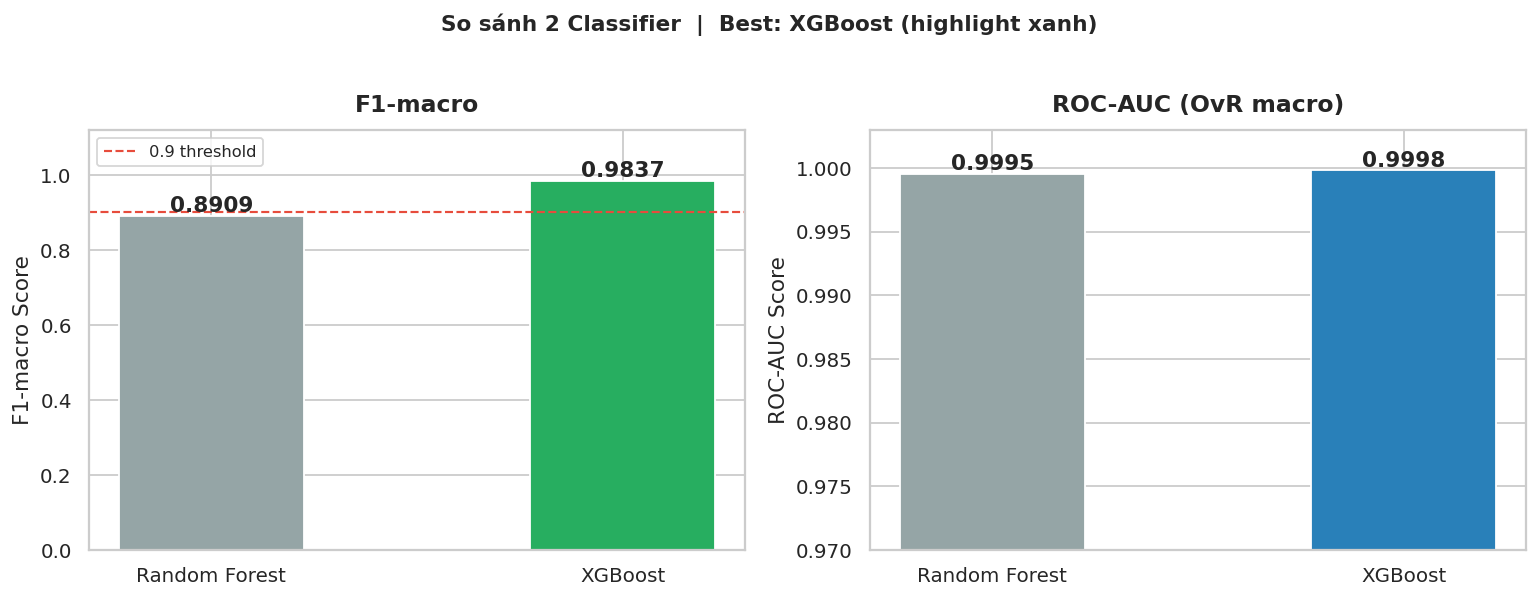

Model                  F1-macro    ROC-AUC
------------------------------------------
Random Forest            0.8909     0.9995
XGBoost                  0.9837     0.9998 ← BEST


In [7]:
models     = ['Random Forest', 'XGBoost']
f1s        = [f1_rf,  f1_xgb]
aucs       = [auc_rf, auc_xgb]
best_idx   = int(np.argmax(f1s))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

bar_colors_f1  = ['#95a5a6', '#95a5a6']
bar_colors_auc = ['#95a5a6', '#95a5a6']
bar_colors_f1[best_idx]  = '#27ae60'
bar_colors_auc[best_idx] = '#2980b9'

# F1-macro
b1 = axes[0].bar(models, f1s, color=bar_colors_f1, edgecolor='white', width=0.45)
axes[0].set_ylim(0, 1.12)
axes[0].set_ylabel('F1-macro Score', fontsize=12)
axes[0].set_title('F1-macro', fontsize=13, fontweight='bold')
axes[0].axhline(0.9, ls='--', color='#e74c3c', lw=1.2, label='0.9 threshold')
axes[0].legend(fontsize=9)
for bar, v in zip(b1, f1s):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.012,
                 f'{v:.4f}', ha='center', fontsize=12, fontweight='bold')

# ROC-AUC
b2 = axes[1].bar(models, aucs, color=bar_colors_auc, edgecolor='white', width=0.45)
axes[1].set_ylim(0.97, 1.003)
axes[1].set_ylabel('ROC-AUC Score', fontsize=12)
axes[1].set_title('ROC-AUC (OvR macro)', fontsize=13, fontweight='bold')
for bar, v in zip(b2, aucs):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.0003,
                 f'{v:.4f}', ha='center', fontsize=12, fontweight='bold')

fig.suptitle(f'So sánh 2 Classifier  |  Best: {models[best_idx]} (highlight xanh)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"{'Model':<20} {'F1-macro':>10} {'ROC-AUC':>10}")
print("-"*42)
for m, f1, auc in zip(models, f1s, aucs):
    flag = " ← BEST" if f1 == max(f1s) else ""
    print(f"{m:<20} {f1:>10.4f} {auc:>10.4f}{flag}")

## 7. F1-score từng class — RF vs XGBoost

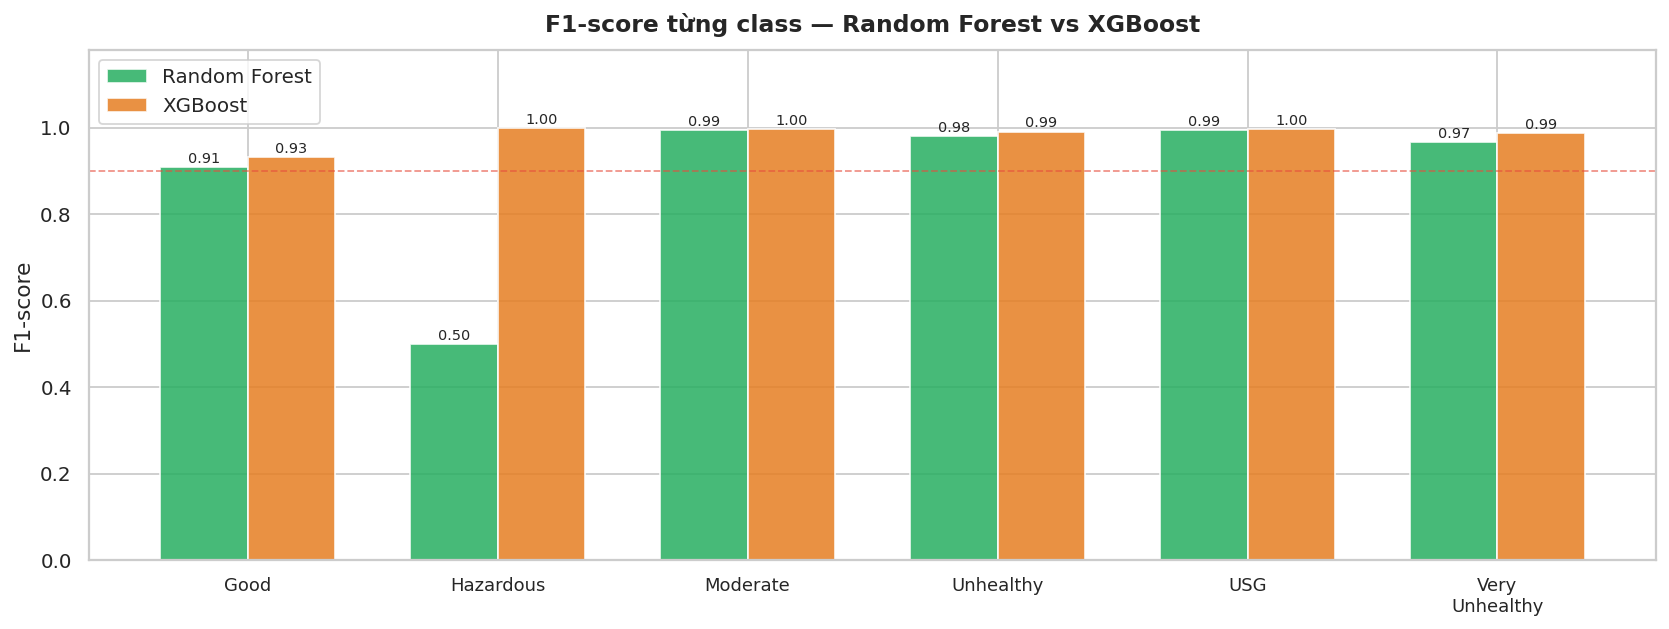

In [8]:
short_labels = ['Good', 'Hazardous', 'Moderate', 'Unhealthy', 'USG', 'Very\nUnhealthy']
x = np.arange(len(le.classes_))
w = 0.35

fig, ax = plt.subplots(figsize=(13, 5))
for i, (mname, pred) in enumerate([('Random Forest', y_pred_rf), ('XGBoost', y_pred_xgb)]):
    report   = classification_report(y_test, pred, output_dict=True, zero_division=0)
    f1_per   = [report[str(k)]['f1-score'] for k in range(len(le.classes_))]
    clr      = ['#27ae60', '#e67e22'][i]
    bars     = ax.bar(x + i*w, f1_per, w, label=mname, color=clr,
                      alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, f1_per):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f'{v:.2f}', ha='center', fontsize=8)

ax.set_xticks(x + w/2)
ax.set_xticklabels(short_labels, fontsize=10)
ax.set_ylim(0, 1.18)
ax.set_ylabel('F1-score', fontsize=12)
ax.set_title('F1-score từng class — Random Forest vs XGBoost', fontsize=13, fontweight='bold')
ax.axhline(0.9, ls='--', color='#e74c3c', lw=1, alpha=0.6)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

## 8. Confusion Matrix trực quan từng class

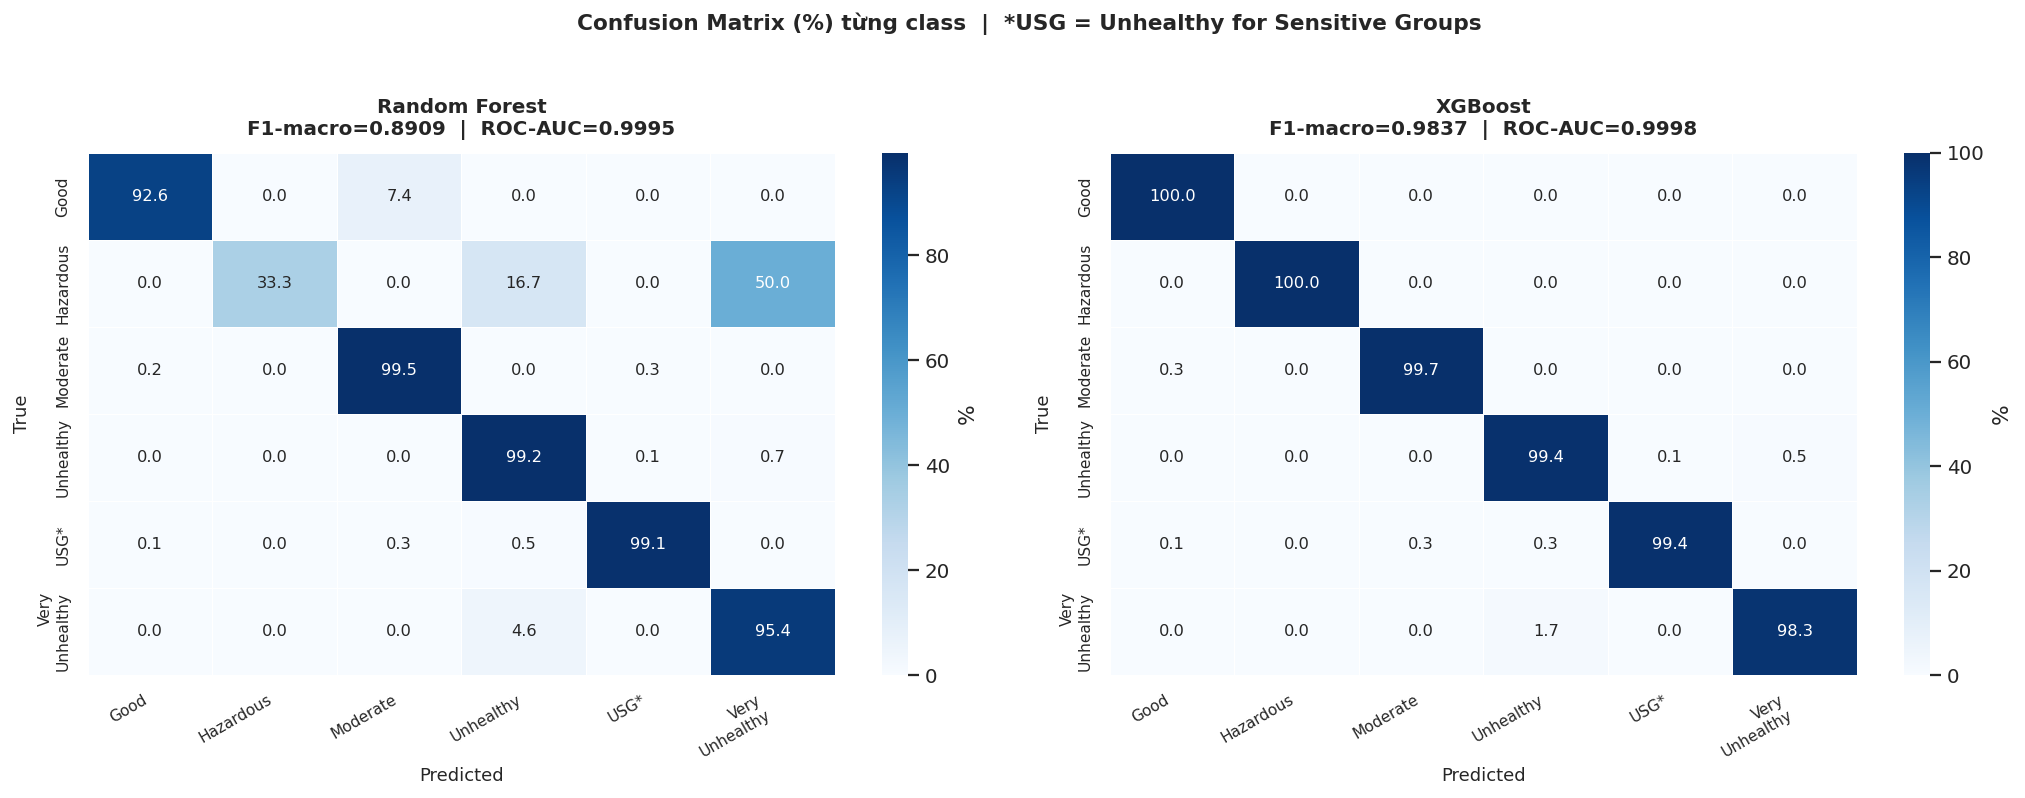

In [9]:
cm_labels = ['Good', 'Hazardous', 'Moderate', 'Unhealthy', 'USG*', 'Very\nUnhealthy']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, (mname, pred, f1, auc) in zip(axes, [
    ('Random Forest', y_pred_rf,  f1_rf,  auc_rf),
    ('XGBoost',       y_pred_xgb, f1_xgb, auc_xgb),
]):
    cm     = confusion_matrix(y_test, pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=cm_labels, yticklabels=cm_labels,
                linewidths=0.5, cbar_kws={'label': '%'}, ax=ax,
                annot_kws={'size': 9})
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=8.5, rotation=30, ha='right')
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=8.5)
    ax.set_title(f'{mname}\nF1-macro={f1:.4f}  |  ROC-AUC={auc:.4f}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('True', fontsize=10)

fig.suptitle('Confusion Matrix (%) từng class  |  *USG = Unhealthy for Sensitive Groups',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 9. Feature Importance — XGBoost

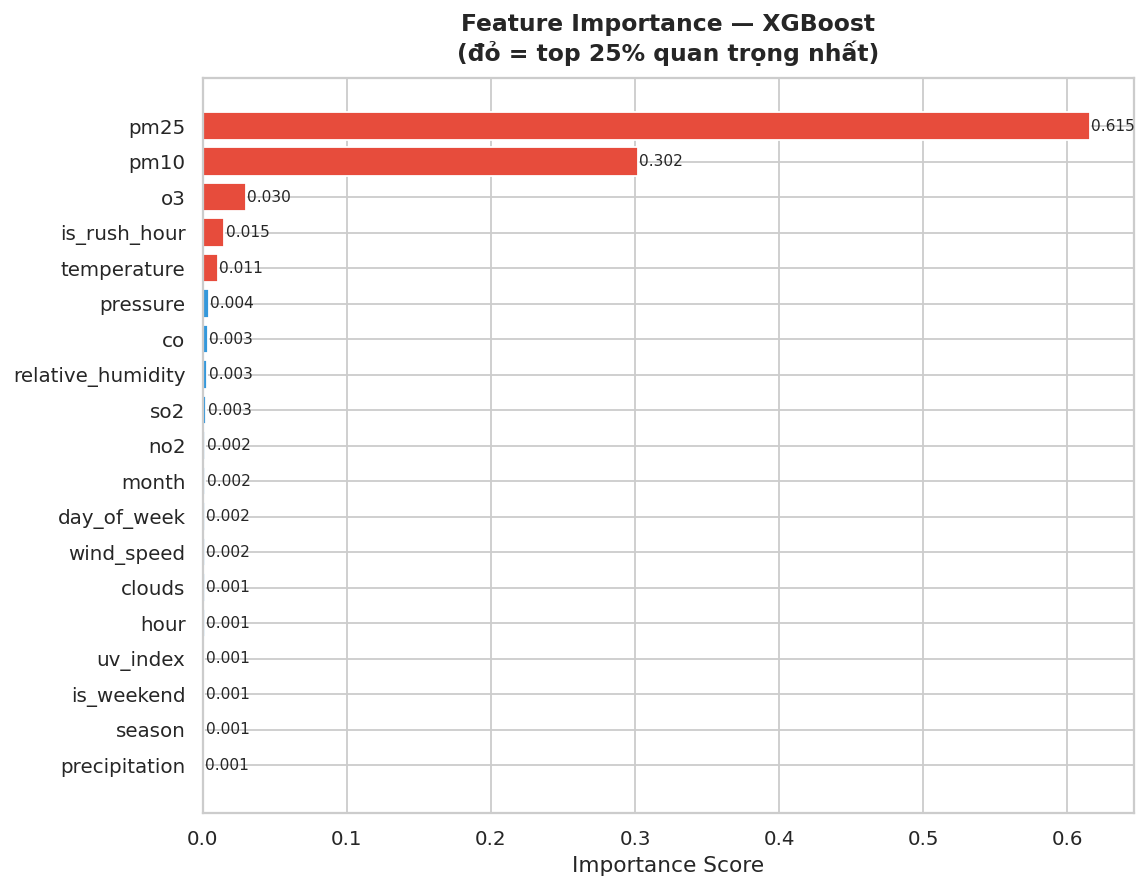

Top 5 features quan trọng nhất (XGBoost):
  pm25                  : 0.6155
  pm10                  : 0.3019
  o3                    : 0.0298
  is_rush_hour          : 0.0150
  temperature           : 0.0106


In [10]:
importances = pd.Series(xgb.feature_importances_, index=FEAT_COLS).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#e74c3c' if v >= importances.quantile(0.75) else '#3498db' for v in importances]
bars   = ax.barh(importances.index, importances.values, color=colors, edgecolor='white')
ax.set_xlabel('Importance Score', fontsize=12)
ax.set_title('Feature Importance — XGBoost\n(đỏ = top 25% quan trọng nhất)',
             fontsize=13, fontweight='bold')

for bar, v in zip(bars, importances.values):
    ax.text(bar.get_width()+0.001, bar.get_y()+bar.get_height()/2,
            f'{v:.3f}', va='center', fontsize=8.5)
plt.tight_layout()
plt.show()

print("Top 5 features quan trọng nhất (XGBoost):")
for feat, val in importances.sort_values(ascending=False).head(5).items():
    print(f"  {feat:<22}: {val:.4f}")

## 10. Tổng kết kết quả

In [11]:
print("=" * 60)
print("  KẾT QUẢ CLASSIFICATION — HÀ NỘI AQI 2022–2025")
print("=" * 60)
print(f"  {'Model':<20} {'F1-macro':>10} {'ROC-AUC':>10}")
print("  " + "-"*42)
for m, f1, auc in zip(models, f1s, aucs):
    flag = "  ← BEST ✅" if f1 == max(f1s) else ""
    print(f"  {m:<20} {f1:>10.4f} {auc:>10.4f}{flag}")
print()
print(f"  File đã lưu: xgboost_best_model.pkl")
print(f"  Features:    {len(FEAT_COLS)} features ({', '.join(FEAT_COLS[:4])}...)")
print("=" * 60)

  KẾT QUẢ CLASSIFICATION — HÀ NỘI AQI 2022–2025
  Model                  F1-macro    ROC-AUC
  ------------------------------------------
  Random Forest            0.8909     0.9995
  XGBoost                  0.9837     0.9998  ← BEST ✅

  File đã lưu: xgboost_best_model.pkl
  Features:    19 features (co, no2, o3, pm10...)
